In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\D JAYA VARDHAN\Downloads\archive (2)\ipl_2026_deliveries.csv")

print(df.head())
print(df.shape)

   match_id  season        phase  match_no          date  \
0    202601    2026  Group Stage         1  Mar 28, 2026   
1    202601    2026  Group Stage         1  Mar 28, 2026   
2    202601    2026  Group Stage         1  Mar 28, 2026   
3    202601    2026  Group Stage         1  Mar 28, 2026   
4    202601    2026  Group Stage         1  Mar 28, 2026   

                              venue batting_team bowling_team  innings  over  \
0  M.Chinnaswamy Stadium, Bengaluru          SRH          RCB        1   0.1   
1  M.Chinnaswamy Stadium, Bengaluru          SRH          RCB        1   0.2   
2  M.Chinnaswamy Stadium, Bengaluru          SRH          RCB        1   0.3   
3  M.Chinnaswamy Stadium, Bengaluru          SRH          RCB        1   0.4   
4  M.Chinnaswamy Stadium, Bengaluru          SRH          RCB        1   0.5   

   ...       bowler runs_of_bat  extras  wide  legbyes  byes  noballs  \
0  ...  Jacob Duffy           0       0     0        0     0        0   
1  ...  Jaco

In [8]:
# Basic Info
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(17477, 21)
['match_id', 'season', 'phase', 'match_no', 'date', 'venue', 'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs', 'wicket_type', 'player_dismissed', 'fielder']
match_id                0
season                  0
phase                   0
match_no                0
date                    0
venue                   0
batting_team            0
bowling_team            0
innings                 0
over                    0
striker                 0
bowler                  0
runs_of_bat             0
extras                  0
wide                    0
legbyes                 0
byes                    0
noballs                 0
wicket_type         16598
player_dismissed    16602
fielder             16791
dtype: int64


C:\Users\D JAYA VARDHAN\AppData\Local\Temp\ipykernel_27584\559045075.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=batsmen, x='runs_of_bat', y='striker', palette='viridis')


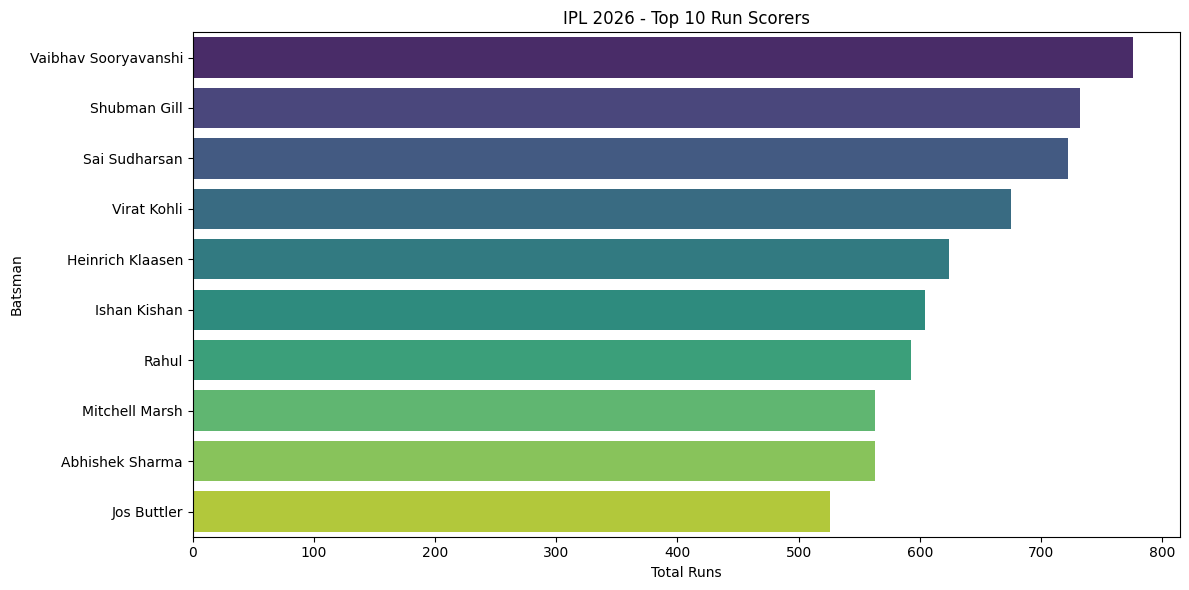

In [9]:
# Top 10 Run Scorers
batsmen = df.groupby('striker')['runs_of_bat'].sum().reset_index()
batsmen = batsmen.sort_values('runs_of_bat', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=batsmen, x='runs_of_bat', y='striker', palette='viridis')
plt.title('IPL 2026 - Top 10 Run Scorers')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

C:\Users\D JAYA VARDHAN\AppData\Local\Temp\ipykernel_27584\2463459635.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strike_rate, x='strike_rate', y='striker', palette='magma')


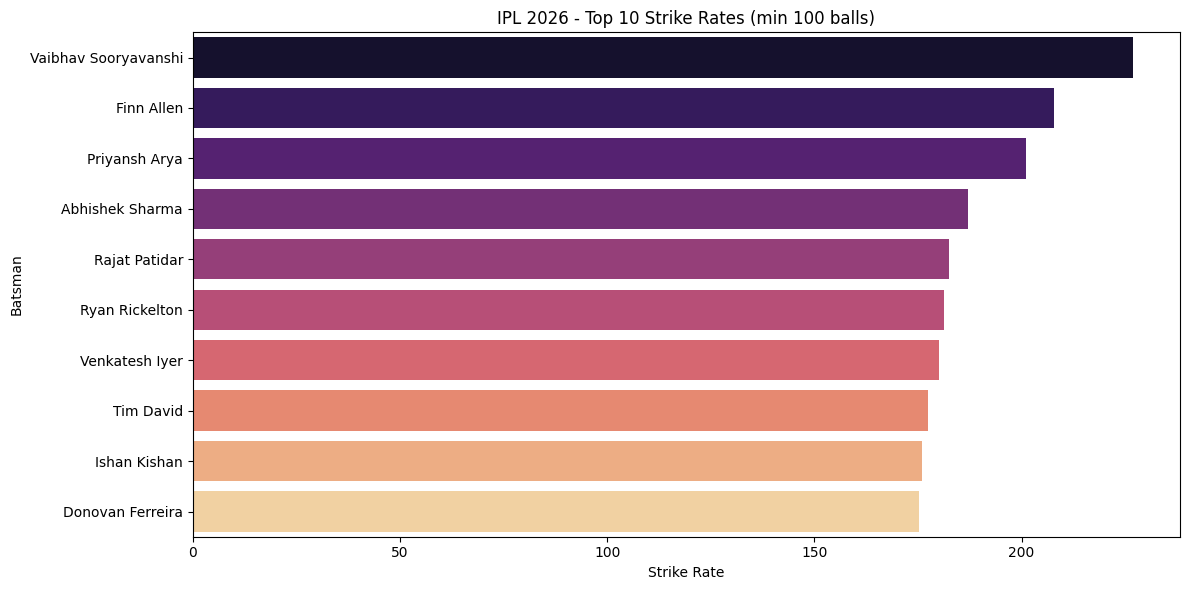

In [10]:
# Strike Rate Analysis
strike_rate = df.groupby('striker').agg(
    runs=('runs_of_bat', 'sum'),
    balls=('runs_of_bat', 'count')
).reset_index()

strike_rate['strike_rate'] = (strike_rate['runs'] / strike_rate['balls']) * 100
strike_rate = strike_rate[strike_rate['balls'] > 100]
strike_rate = strike_rate.sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=strike_rate, x='strike_rate', y='striker', palette='magma')
plt.title('IPL 2026 - Top 10 Strike Rates (min 100 balls)')
plt.xlabel('Strike Rate')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

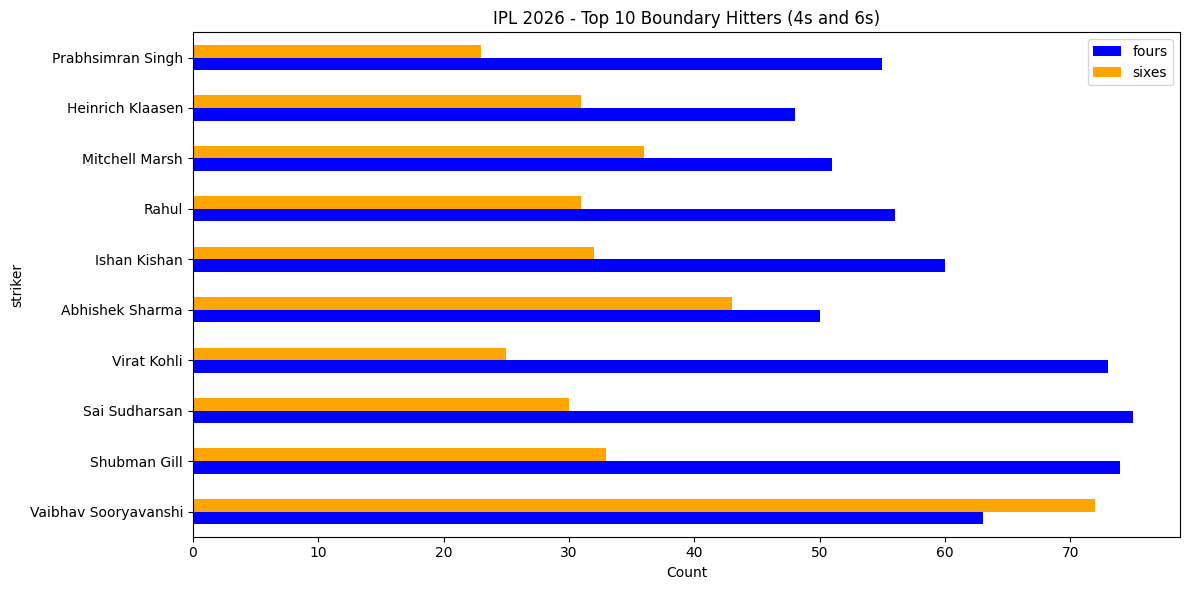

In [11]:
# Boundaries - 4s and 6s
fours = df[df['runs_of_bat'] == 4].groupby('striker').size().reset_index(name='fours')
sixes = df[df['runs_of_bat'] == 6].groupby('striker').size().reset_index(name='sixes')

boundaries = fours.merge(sixes, on='striker')
boundaries['total_boundaries'] = boundaries['fours'] + boundaries['sixes']
boundaries = boundaries.sort_values('total_boundaries', ascending=False).head(10)

plt.figure(figsize=(12,6))
boundaries.set_index('striker')[['fours','sixes']].plot(kind='barh', figsize=(12,6), color=['blue','orange'])
plt.title('IPL 2026 - Top 10 Boundary Hitters (4s and 6s)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

C:\Users\D JAYA VARDHAN\AppData\Local\Temp\ipykernel_27584\2984012127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_runs, x='runs_of_bat', y='batting_team', palette='coolwarm')


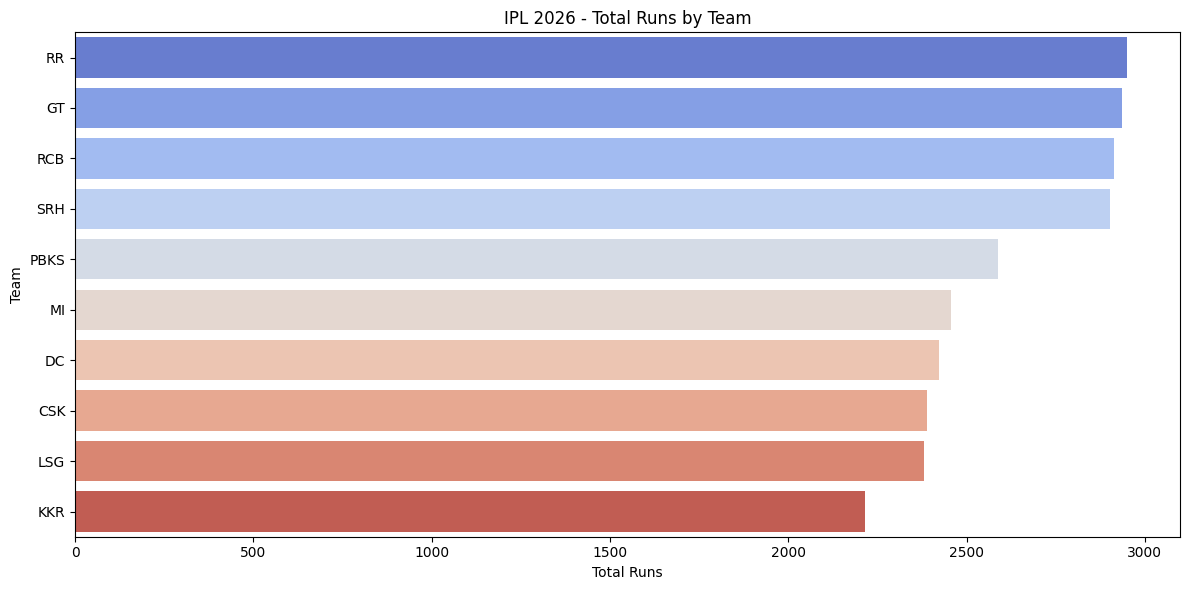

In [12]:
# Team Total Runs
team_runs = df.groupby('batting_team')['runs_of_bat'].sum().reset_index()
team_runs = team_runs.sort_values('runs_of_bat', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=team_runs, x='runs_of_bat', y='batting_team', palette='coolwarm')
plt.title('IPL 2026 - Total Runs by Team')
plt.xlabel('Total Runs')
plt.ylabel('Team')
plt.tight_layout()
plt.show()